# Previsão de Churn de Clientes — Interconnect (Telecom)
### Projeto Final | Formação em Ciência de Dados

Este notebook reúne todo o projeto final, do entendimento do problema até o modelo
treinado e as recomendações de negócio. Ele passa, na prática, por boa parte das
competências da formação: **Python e pandas**, **análise e estatística de dados (EDA)**,
**preparação de dados** e **machine learning supervisionado** de ponta a ponta (modelo de
referência, comparação de algoritmos, ajuste de hiperparâmetros e avaliação).

---

## Contexto de negócio

A **Interconnect** é uma operadora de telecomunicações que oferece telefonia fixa e internet
(DSL ou fibra), além de serviços como segurança, suporte técnico, backup e streaming. A
equipe de marketing quer **antecipar quais clientes estão prestes a cancelar (churn)** para
agir antes, com desconto e ofertas de retenção. Reter sai mais barato do que conquistar um
cliente novo, então prever o churn ajuda a direcionar a verba de retenção para quem realmente
está em risco.

**Decisões que guiaram o projeto:**

- É um problema de **classificação binária**: `EndDate` com data → cancelou (`Churn = 1`);
  `"No"` → ativo (`Churn = 0`).
- Divisão treino/teste **aleatória estratificada**.
- Data de referência para o tempo de casa: **01/02/2020**.
- O erro mais caro é o **falso negativo** (perder um cliente sem agir), então olho bastante
  o **recall** da classe "cancelou".
- Métrica principal: **ROC-AUC** (meta: ≥ 0,75 útil; ≥ 0,80 bom).

## 1. Bibliotecas e carga dos dados

Deixo o caminho dos dados e a semente aleatória no topo, para o notebook ser fácil de
reproduzir.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, RandomizedSearchCV)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             precision_recall_curve, recall_score, precision_score, f1_score)
from lightgbm import LGBMClassifier

RANDOM_STATE = 42
DATA_DIR = "projeto"   # <-- ajuste aqui se os CSVs estiverem em outra pasta

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)

contract = pd.read_csv(f"{DATA_DIR}/contract.csv")
personal = pd.read_csv(f"{DATA_DIR}/personal.csv")
internet = pd.read_csv(f"{DATA_DIR}/internet.csv")
phone    = pd.read_csv(f"{DATA_DIR}/phone.csv")

# Checagem defensiva: garante que cada arquivo é o esperado
esperado = {
    "contract": {"customerID", "BeginDate", "EndDate", "Type", "MonthlyCharges", "TotalCharges"},
    "personal": {"customerID", "gender", "SeniorCitizen", "Partner", "Dependents"},
    "internet": {"customerID", "InternetService", "OnlineSecurity", "StreamingTV"},
    "phone":    {"customerID", "MultipleLines"},
}
for nome, dframe in [("contract", contract), ("personal", personal),
                     ("internet", internet), ("phone", phone)]:
    faltando = esperado[nome] - set(dframe.columns)
    assert not faltando, f"{nome}.csv parece errado — faltam colunas: {faltando}"
print("Arquivos OK:", contract.shape, personal.shape, internet.shape, phone.shape)

Arquivos OK: (7043, 8) (7043, 5) (5517, 8) (6361, 2)


## 2. Limpeza e montagem do dataset

As quatro fontes têm 1 linha por cliente e se ligam pelo `customerID`. Junto tudo e trato:

- **`NaN` de serviço** (cliente sem internet/telefone) → vira rótulo próprio, não é apagado.
- **`TotalCharges`** veio como texto, com 11 espaços em branco (clientes novos) → vira número, com 0 no lugar do vazio.
- **`Churn`** é criado a partir do `EndDate`.
- **`TenureMonths`** (tempo de casa) é calculado com referência em 01/02/2020.

In [2]:
# Junção das quatro fontes
df = (contract
      .merge(personal, on="customerID", how="left")
      .merge(internet, on="customerID", how="left")
      .merge(phone,    on="customerID", how="left"))

df["HasInternet"] = df["InternetService"].notna().astype(int)
df["HasPhone"]    = df["MultipleLines"].notna().astype(int)

internet_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                 "TechSupport", "StreamingTV", "StreamingMovies"]
df["InternetService"] = df["InternetService"].fillna("No internet")
df[internet_cols] = df[internet_cols].fillna("No internet service")
df["MultipleLines"] = df["MultipleLines"].fillna("No phone service")

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)
df["Churn"] = (df["EndDate"] != "No").astype(int)

begin = pd.to_datetime(df["BeginDate"], errors="coerce")
end   = pd.to_datetime(df["EndDate"].replace("No", np.nan), errors="coerce")
fim   = end.fillna(pd.Timestamp("2020-02-01"))
df["TenureMonths"] = ((fim.dt.year - begin.dt.year) * 12
                      + (fim.dt.month - begin.dt.month)).clip(lower=0)

print("Shape final:", df.shape)
print("Sem clientes duplicados:", df["customerID"].is_unique)

Shape final: (7043, 24)
Sem clientes duplicados: True


## 3. Análise exploratória (EDA)

Antes de modelar, exploro os dados para entender o churn e levantar quais variáveis parecem
importar mais.

Distribuição do churn (%):
Churn
Ativo       73.46
Cancelou    26.54
Name: proportion, dtype: float64


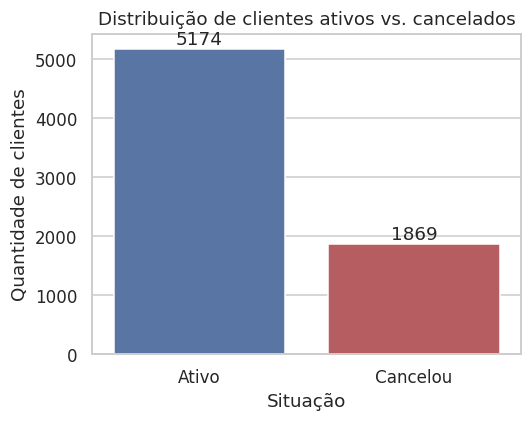

In [3]:
dist = (df["Churn"].value_counts(normalize=True) * 100).round(2)
print("Distribuição do churn (%):")
print(dist.rename({0: "Ativo", 1: "Cancelou"}))

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x=df["Churn"].map({0: "Ativo", 1: "Cancelou"}),
              order=["Ativo", "Cancelou"], ax=ax, palette=["#4C72B0", "#C44E52"])
ax.set_title("Distribuição de clientes ativos vs. cancelados")
ax.set_xlabel("Situação"); ax.set_ylabel("Quantidade de clientes")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout(); plt.show()

Cerca de **26,5%** dos clientes cancelaram — um desbalanceamento moderado. Isso já avisa
que a **acurácia não serve** como métrica (um modelo que chuta "ninguém sai" acerta ~73%) e
que vou precisar tratar o desbalanceamento no treino.

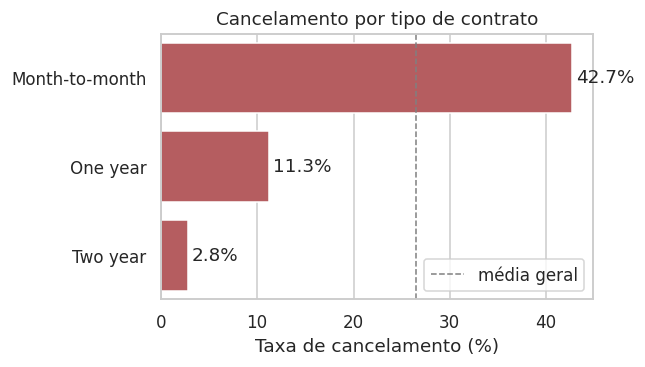

In [4]:
def churn_por_categoria(coluna, titulo):
    """Mostra a taxa de cancelamento (%) dentro de cada categoria."""
    taxa = df.groupby(coluna)["Churn"].mean().sort_values(ascending=False) * 100
    fig, ax = plt.subplots(figsize=(6, 3.5))
    sns.barplot(x=taxa.values, y=taxa.index, ax=ax, color="#C44E52")
    ax.axvline(df["Churn"].mean() * 100, ls="--", color="gray", lw=1, label="média geral")
    ax.set_title(titulo); ax.set_xlabel("Taxa de cancelamento (%)"); ax.set_ylabel("")
    for i, v in enumerate(taxa.values):
        ax.text(v + 0.4, i, f"{v:.1f}%", va="center")
    ax.legend(); plt.tight_layout(); plt.show()

churn_por_categoria("Type", "Cancelamento por tipo de contrato")

Contrato **mês a mês** cancela muito mais do que contratos de 1 ou 2 anos — de longe o
fator mais forte.

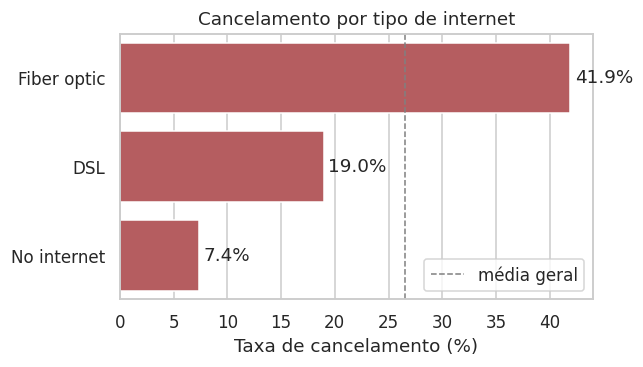

In [5]:
churn_por_categoria("InternetService", "Cancelamento por tipo de internet")

Clientes de **fibra óptica** cancelam mais (provável relação com preço/expectativa).

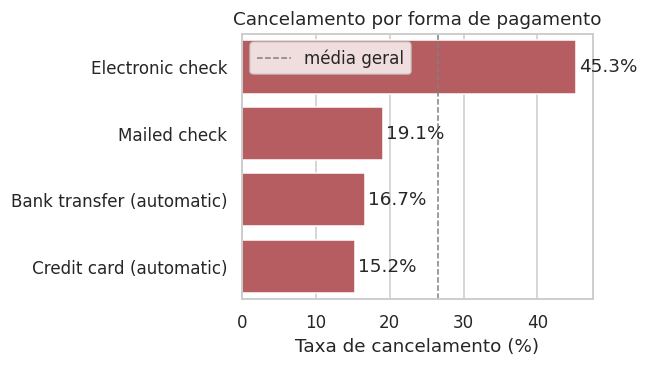

In [6]:
churn_por_categoria("PaymentMethod", "Cancelamento por forma de pagamento")

O **cheque eletrônico** se destaca com churn alto; pagamentos automáticos retêm mais.

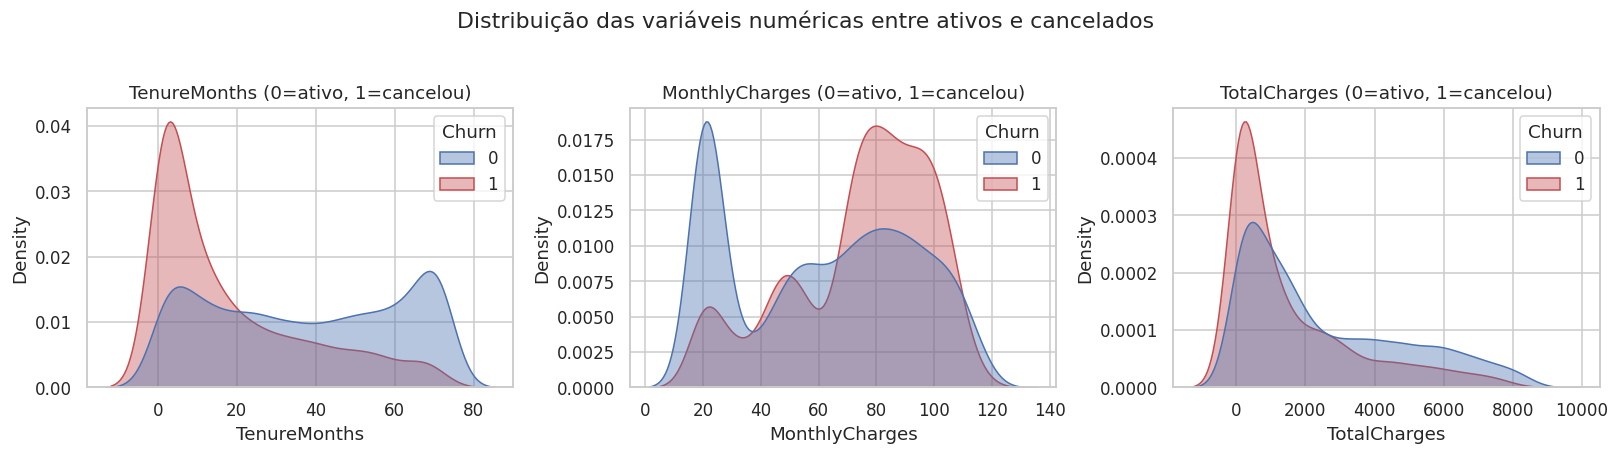

In [7]:
# Variáveis numéricas por situação
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["TenureMonths", "MonthlyCharges", "TotalCharges"]):
    sns.kdeplot(data=df, x=col, hue="Churn", common_norm=False, fill=True, alpha=0.4, ax=ax,
                palette={0: "#4C72B0", 1: "#C44E52"})
    ax.set_title(f"{col} (0=ativo, 1=cancelou)")
fig.suptitle("Distribuição das variáveis numéricas entre ativos e cancelados", y=1.03)
plt.tight_layout(); plt.show()

**Resumo da EDA:** quem cancela tende a ter **pouco tempo de casa**, **mensalidade mais
alta** e total acumulado baixo. Junto com contrato mensal, fibra e cheque eletrônico, esses
são os principais candidatos a bons preditores.

## 4. Engenharia de atributos

Crio três variáveis derivadas que fazem sentido no contexto:

- **`NumServicos`** — quantos serviços o cliente contrata (quanto mais, mais "preso").
- **`ChargesPorServico`** — quanto paga por serviço (mensalidade ÷ nº de serviços).
- **`FaixaTenure`** — o tempo de casa agrupado em faixas.

E deixo de fora do modelo, de propósito: **`EndDate`** (é a origem do alvo → vazamento),
**`BeginDate`** (já virou `TenureMonths`) e **`customerID`** (só identificador).

In [8]:
serv_extras = df[internet_cols].apply(lambda col: col.eq("Yes")).sum(axis=1)
df["NumServicos"] = serv_extras + df["MultipleLines"].eq("Yes").astype(int) + df["HasPhone"]
df["ChargesPorServico"] = (df["MonthlyCharges"] / (df["NumServicos"] + 1)).round(2)
df["FaixaTenure"] = pd.cut(df["TenureMonths"], bins=[-1, 6, 24, np.inf],
                           labels=["0-6 meses", "7-24 meses", "25+ meses"])

df[["NumServicos", "ChargesPorServico", "TenureMonths", "FaixaTenure"]].head()

,NumServicos,ChargesPorServico,TenureMonths,FaixaTenure
0,1,14.92,1,0-6 meses
1,3,14.24,34,25+ meses
2,3,13.46,2,0-6 meses
3,3,10.58,45,25+ meses
4,1,35.35,2,0-6 meses


## 5. Preparação para o modelo

Separo `X`/`y`, identifico colunas numéricas e categóricas, divido em treino/teste de forma
**estratificada** e monto um pré-processador (padroniza numéricas + One-Hot nas categóricas)
dentro de um `Pipeline`, ajustando **só no treino** para não vazar informação.

Para o desbalanceamento, uso `class_weight="balanced"` nos modelos — dá mais peso à classe
minoritária ("cancelou") sem inventar dados sintéticos.

In [9]:
X = df.drop(columns=["customerID", "BeginDate", "EndDate", "Churn"])
y = df["Churn"]

num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]
print("Numéricas :", num_cols)
print("Categóricas:", cat_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
print(f"\nTreino: {X_train.shape[0]} | Teste: {X_test.shape[0]}")

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

Numéricas : ['MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'HasInternet', 'HasPhone', 'TenureMonths', 'NumServicos', 'ChargesPorServico']
Categóricas: ['Type', 'PaperlessBilling', 'PaymentMethod', 'gender', 'Partner', 'Dependents', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines', 'FaixaTenure']

Treino: 5282 | Teste: 1761


## 6. Modelo de referência (baseline)

Antes dos modelos "espertos", crio um `DummyClassifier`, que só chuta a classe mais comum.
Ele é o piso: qualquer modelo útil tem que superá-lo. Também defino uma função de avaliação
para usar a mesma régua em todos.

In [10]:
def avalia(nome, modelo, X_te, y_te):
    """Treina já feito; calcula as métricas no teste."""
    proba = modelo.predict_proba(X_te)[:, 1]
    pred = modelo.predict(X_te)
    print(f"{nome}: AUC={roc_auc_score(y_te, proba):.3f} | "
          f"Recall={recall_score(y_te, pred):.3f} | "
          f"Precision={precision_score(y_te, pred, zero_division=0):.3f} | "
          f"F1={f1_score(y_te, pred):.3f}")

dummy = Pipeline([("pre", preprocess),
                  ("clf", DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE))])
dummy.fit(X_train, y_train)
avalia("Dummy (base)", dummy, X_test, y_test)

Dummy (base): AUC=0.500 | Recall=0.000 | Precision=0.000 | F1=0.000


Como esperado, o dummy tem **AUC ≈ 0,5** e **recall 0** — não identifica ninguém que
vai cancelar. É o piso a ser superado.

## 7. Comparação inicial dos três modelos

Treino os três algoritmos do plano (Regressão Logística, Random Forest e LightGBM) com
configuração padrão e comparo por **validação cruzada estratificada (5 folds)** no ROC-AUC.

In [11]:
modelos = {
    "Regressão Logística": LogisticRegression(max_iter=1000, class_weight="balanced",
                                              random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(class_weight="balanced", n_jobs=-1,
                                            random_state=RANDOM_STATE),
    "LightGBM": LGBMClassifier(class_weight="balanced", random_state=RANDOM_STATE, verbose=-1),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for nome, clf in modelos.items():
    pipe = Pipeline([("pre", preprocess), ("clf", clf)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")
    print(f"{nome:22s} AUC = {scores.mean():.4f} (+/- {scores.std():.4f})")

Regressão Logística    AUC = 0.8467 (+/- 0.0169)


Random Forest          AUC = 0.8216 (+/- 0.0124)


LightGBM               AUC = 0.8333 (+/- 0.0117)


Os três já passam a meta mínima (0,75). Agora vou **ajustar os hiperparâmetros dos
três** e só então escolher o melhor — comparação justa.

## 8. Ajuste de hiperparâmetros dos três modelos

Uso `RandomizedSearchCV` (busca aleatória) em cada modelo. É mais eficiente que testar todas
as combinações: sorteia um número fixo de candidatos e fica com o melhor pela validação
cruzada. O `n_iter` é calculado para nunca passar o total de combinações (evita erro em
versões antigas do scikit-learn).

In [12]:
espacos = {
    "Regressão Logística": (
        LogisticRegression(max_iter=1000, class_weight="balanced",
                           solver="liblinear", random_state=RANDOM_STATE),
        {"clf__C": [0.01, 0.05, 0.1, 0.5, 1, 5, 10], "clf__penalty": ["l1", "l2"]},
    ),
    "Random Forest": (
        RandomForestClassifier(class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE),
        {"clf__n_estimators": [100, 200, 300, 400], "clf__max_depth": [4, 6, 8, 10, None],
         "clf__min_samples_leaf": [1, 2, 5, 10], "clf__max_features": ["sqrt", "log2", None]},
    ),
    "LightGBM": (
        LGBMClassifier(class_weight="balanced", random_state=RANDOM_STATE, verbose=-1),
        {"clf__n_estimators": [100, 200, 300, 500], "clf__num_leaves": [15, 31, 63],
         "clf__learning_rate": [0.01, 0.05, 0.1], "clf__max_depth": [-1, 4, 6, 8]},
    ),
}

ajustados, linhas = {}, []
for nome, (clf, grade) in espacos.items():
    pipe = Pipeline([("pre", preprocess), ("clf", clf)])
    total = int(np.prod([len(v) for v in grade.values()]))
    busca = RandomizedSearchCV(pipe, grade, n_iter=min(25, total), cv=cv,
                               scoring="roc_auc", random_state=RANDOM_STATE, n_jobs=-1)
    busca.fit(X_train, y_train)
    ajustados[nome] = busca.best_estimator_
    linhas.append({"modelo": nome, "AUC_ajustado": busca.best_score_})
    print(f"{nome:22s} AUC = {busca.best_score_:.4f} | {busca.best_params_}")

tuning = pd.DataFrame(linhas).sort_values("AUC_ajustado", ascending=False).reset_index(drop=True)
tuning

Regressão Logística    AUC = 0.8467 | {'clf__penalty': 'l1', 'clf__C': 10}


Random Forest          AUC = 0.8454 | {'clf__n_estimators': 200, 'clf__min_samples_leaf': 10, 'clf__max_features': 'sqrt', 'clf__max_depth': 8}


LightGBM               AUC = 0.8443 | {'clf__num_leaves': 15, 'clf__n_estimators': 300, 'clf__max_depth': 4, 'clf__learning_rate': 0.01}


,modelo,AUC_ajustado
0,Regressão Logística,0.846716
1,Random Forest,0.845370
2,LightGBM,0.844300


Melhor modelo após ajuste: Regressão Logística
AUC (validação cruzada): 0.8467


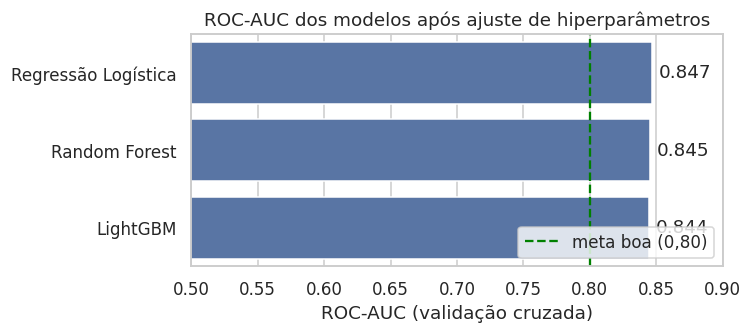

In [13]:
# O melhor modelo é o de maior AUC DEPOIS do ajuste
nome_melhor = tuning.iloc[0]["modelo"]
modelo_final = ajustados[nome_melhor]
print(f"Melhor modelo após ajuste: {nome_melhor}")
print(f"AUC (validação cruzada): {tuning.iloc[0]['AUC_ajustado']:.4f}")

fig, ax = plt.subplots(figsize=(7, 3.2))
sns.barplot(data=tuning, x="AUC_ajustado", y="modelo", ax=ax, color="#4C72B0")
ax.axvline(0.80, ls="--", color="green", label="meta boa (0,80)")
ax.set_xlim(0.5, 0.9); ax.set_title("ROC-AUC dos modelos após ajuste de hiperparâmetros")
ax.set_xlabel("ROC-AUC (validação cruzada)"); ax.set_ylabel(""); ax.legend(loc="lower right")
for i, v in enumerate(tuning["AUC_ajustado"]):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center")
plt.tight_layout(); plt.show()

Depois do ajuste os três ficam **praticamente empatados** (todos perto de 0,84-0,85).
O Random Forest e o LightGBM melhoraram bastante com o tuning, mas a **Regressão Logística**
seguiu na frente — e, por ser a mais simples e fácil de explicar, é a melhor escolha. Sigo
com ela como modelo final.

## 9. Avaliação no conjunto de teste

Aplico o modelo escolhido nos dados de teste, que ele nunca viu. Comparo o AUC de treino e de
teste para checar **overfitting** e mostro a matriz de confusão e a curva ROC.

In [14]:
auc_train = roc_auc_score(y_train, modelo_final.predict_proba(X_train)[:, 1])
auc_test  = roc_auc_score(y_test,  modelo_final.predict_proba(X_test)[:, 1])
print(f"AUC treino: {auc_train:.4f} | AUC teste: {auc_test:.4f} | diferença: {auc_train - auc_test:.4f}")

y_pred = modelo_final.predict(X_test)
print("\nRelatório de classificação (limiar 0,5):")
print(classification_report(y_test, y_pred, target_names=["Ativo", "Cancelou"]))

AUC treino: 0.8511 | AUC teste: 0.8485 | diferença: 0.0026

Relatório de classificação (limiar 0,5):
              precision    recall  f1-score   support

       Ativo       0.91      0.73      0.81      1294
    Cancelou       0.52      0.81      0.63       467

    accuracy                           0.75      1761
   macro avg       0.72      0.77      0.72      1761
weighted avg       0.81      0.75      0.76      1761



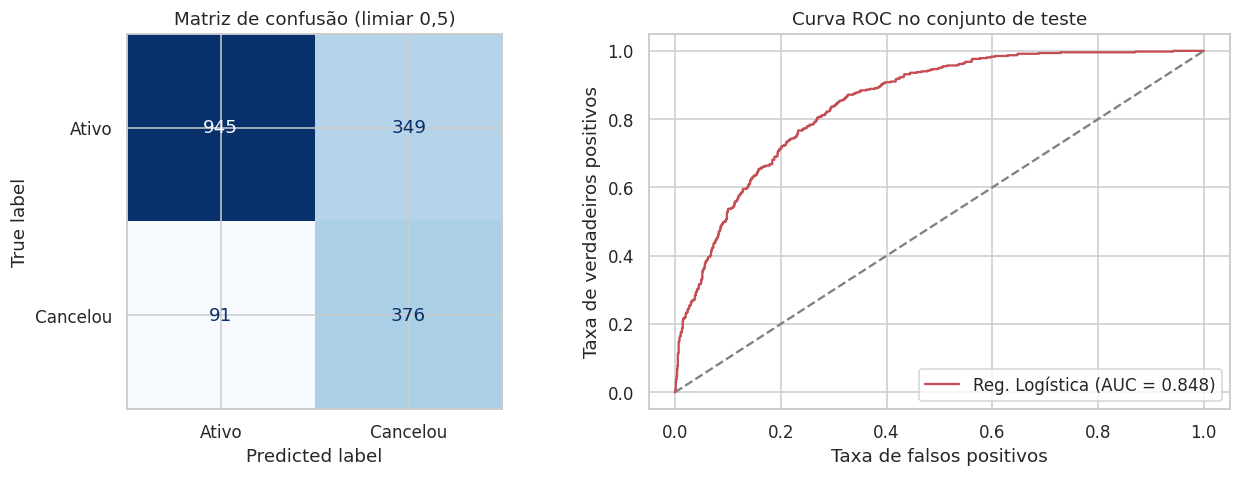

In [15]:
proba_test = modelo_final.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Ativo", "Cancelou"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Matriz de confusão (limiar 0,5)")

# Curva ROC desenhada na mão (compatível com qualquer versão do scikit-learn)
fpr, tpr, _ = roc_curve(y_test, proba_test)
axes[1].plot(fpr, tpr, color="#C44E52", label=f"Reg. Logística (AUC = {auc_test:.3f})")
axes[1].plot([0, 1], [0, 1], ls="--", color="gray")
axes[1].set_xlabel("Taxa de falsos positivos"); axes[1].set_ylabel("Taxa de verdadeiros positivos")
axes[1].set_title("Curva ROC no conjunto de teste"); axes[1].legend(loc="lower right")
plt.tight_layout(); plt.show()

O AUC de treino e de teste ficam **bem próximos** → **não há overfitting**, o modelo
generaliza. O AUC de teste fica na faixa boa (perto de 0,84), acima da meta.

## 10. Calibração do limiar (priorizando o recall)

Por padrão o modelo decide "vai cancelar" com probabilidade ≥ 0,5. Mas como **falso negativo
é o erro mais caro**, fixo uma **meta de recall de 0,85** (capturar 85% de quem cancela) e
escolho o maior limiar que ainda atinge essa meta — assim garanto o recall perdendo o mínimo
de precisão.

Limiar para recall >= 0.85: 0.431
Nesse ponto -> Recall: 0.850 | Precisão: 0.499


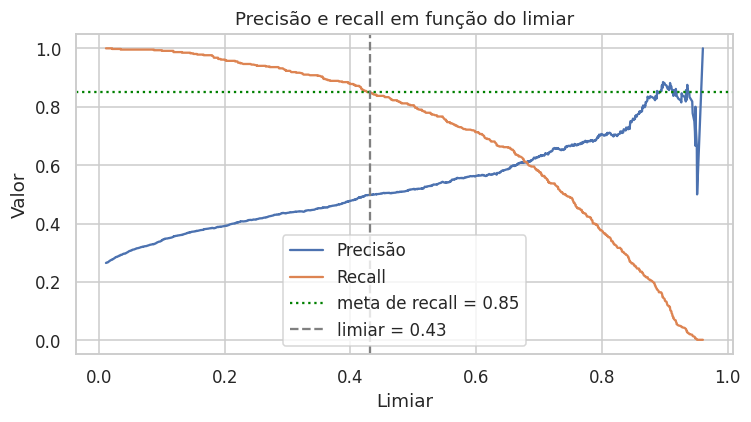

In [16]:
precisao, recall, limiares = precision_recall_curve(y_test, proba_test)
RECALL_ALVO = 0.85
mask = recall[:-1] >= RECALL_ALVO
limiar = limiares[mask].max()
idx = np.where(limiares == limiar)[0][0]
print(f"Limiar para recall >= {RECALL_ALVO}: {limiar:.3f}")
print(f"Nesse ponto -> Recall: {recall[idx]:.3f} | Precisão: {precisao[idx]:.3f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(limiares, precisao[:-1], label="Precisão")
ax.plot(limiares, recall[:-1], label="Recall")
ax.axhline(RECALL_ALVO, ls=":", color="green", label=f"meta de recall = {RECALL_ALVO}")
ax.axvline(limiar, ls="--", color="gray", label=f"limiar = {limiar:.2f}")
ax.set_title("Precisão e recall em função do limiar"); ax.set_xlabel("Limiar"); ax.set_ylabel("Valor")
ax.legend(); plt.tight_layout(); plt.show()

In [17]:
y_pred_calib = (proba_test >= limiar).astype(int)
print("Limiar padrão (0,5) -> Recall:", round(recall_score(y_test, y_pred), 3),
      "| Precisão:", round(precision_score(y_test, y_pred), 3))
print(f"Limiar calibrado ({limiar:.2f}) -> Recall:", round(recall_score(y_test, y_pred_calib), 3),
      "| Precisão:", round(precision_score(y_test, y_pred_calib), 3))

Limiar padrão (0,5) -> Recall: 0.805 | Precisão: 0.519
Limiar calibrado (0.43) -> Recall: 0.85 | Precisão: 0.499


Baixando o limiar, o modelo captura **mais clientes em risco** (recall maior), ao custo
de contatar alguns que ficariam. Esse é o trade-off desejado: como perder cliente é mais
caro, aceitamos alguns alarmes falsos. O ponto exato deve ser combinado com o marketing,
conforme quantos clientes a equipe consegue contatar por mês.

## 11. Importância das variáveis

Como o modelo final é uma regressão logística, leio os **coeficientes**: quanto maior o valor
absoluto, mais a variável pesa. (O código também funciona se o melhor modelo for de árvore,
usando a importância.)

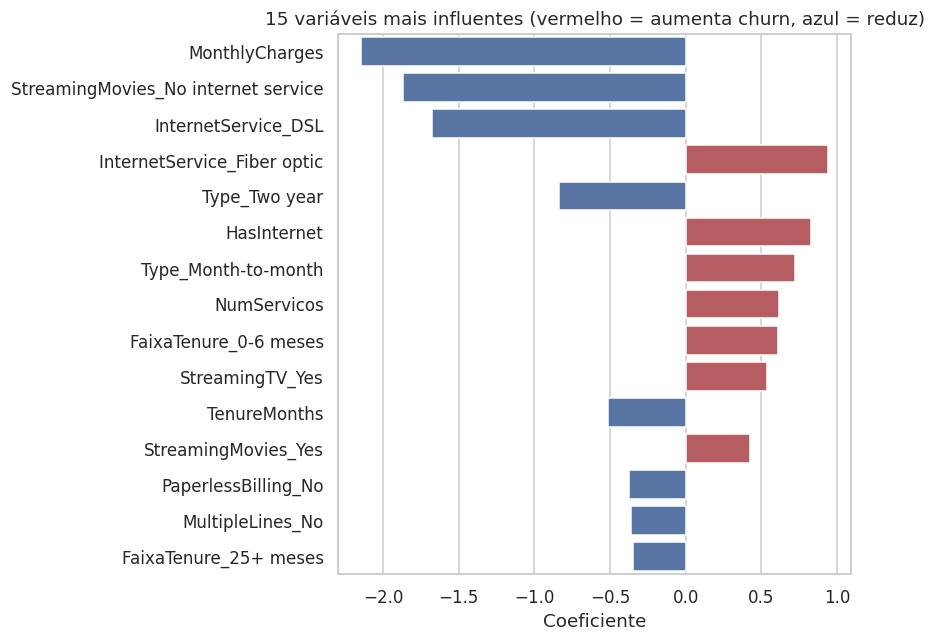

,variavel,coeficiente
0,MonthlyCharges,-2.143543
1,StreamingMovies_No internet service,-1.868489
2,InternetService_DSL,-1.679538
3,InternetService_Fiber optic,0.940914
4,Type_Two year,-0.837879
5,HasInternet,0.828795
6,Type_Month-to-month,0.724749
7,NumServicos,0.615569
8,FaixaTenure_0-6 meses,0.608099
9,StreamingTV_Yes,0.539465


In [18]:
clf_final = modelo_final.named_steps["clf"]
ohe = modelo_final.named_steps["pre"].named_transformers_["cat"]

# Nomes das colunas após o pré-processamento (compatível com versões novas e antigas do sklearn)
try:
    nomes_cat = list(ohe.get_feature_names_out(cat_cols))   # sklearn >= 1.0
except AttributeError:
    nomes_cat = list(ohe.get_feature_names(cat_cols))       # sklearn 0.24
nomes = list(num_cols) + nomes_cat

if hasattr(clf_final, "coef_"):          # modelo linear
    valores = clf_final.coef_[0]; rotulo, eh_coef = "coeficiente", True
    titulo = "15 variáveis mais influentes (vermelho = aumenta churn, azul = reduz)"
else:                                     # árvores
    valores = clf_final.feature_importances_; rotulo, eh_coef = "importancia", False
    titulo = "15 variáveis mais importantes do modelo"

importancia = (pd.DataFrame({"variavel": nomes, rotulo: valores})
               .assign(peso=lambda d: d[rotulo].abs())
               .sort_values("peso", ascending=False).head(15))

fig, ax = plt.subplots(figsize=(8, 6))
if eh_coef:
    cores = ["#C44E52" if v > 0 else "#4C72B0" for v in importancia[rotulo]]
    sns.barplot(data=importancia, x=rotulo, y="variavel", palette=cores, ax=ax)
else:
    sns.barplot(data=importancia, x=rotulo, y="variavel", color="#4C72B0", ax=ax)
ax.set_title(titulo); ax.set_xlabel(rotulo.capitalize()); ax.set_ylabel("")
plt.tight_layout(); plt.show()
importancia[["variavel", rotulo]].reset_index(drop=True)

Os pesos confirmam a EDA: **contrato mês a mês**, **pouco tempo de casa**, **fibra** e
**cheque eletrônico** puxam o churn para cima; contratos longos e mais tempo de casa seguram
o cliente. O modelo está capturando relações que fazem sentido no negócio.

## 12. Conclusões, recomendações e limitações

**Resultado.** Saí de um modelo de referência inútil (AUC ≈ 0,5) para uma **Regressão
Logística** com **ROC-AUC ≈ 0,84** no teste — acima da meta de 0,80, estável (sem
overfitting) e interpretável. Depois de ajustar os três modelos, ela se manteve à frente do
Random Forest e do LightGBM.

**Principais fatores de churn:** contrato mês a mês, pouco tempo de casa, internet por fibra,
pagamento por cheque eletrônico e ausência de serviços de suporte/segurança.

**Recomendações (segmentando por risco):**

- **Risco alto:** ação proativa e mais forte — desconto, migração de mês a mês para contrato
  anual, suporte/segurança grátis por um período.
- **Risco médio:** ações leves — comunicação de benefícios, incentivo para anualizar.
- **Risco baixo:** não gastar verba de retenção; focar em relacionamento e venda de serviços.

O limiar de decisão deve ser calibrado conforme a capacidade de contato do time (mais
capacidade → limiar mais baixo → mais recall).

**Limitações:** a janela de cancelamentos observada é curta (out/2019 a jan/2020); o
`TenureMonths` depende da data de referência assumida; não há dados de uso/qualidade de rede
nem reclamações, que provavelmente melhorariam a previsão; e o modelo aponta **correlação**,
não causa.

**Próximos passos:** validar o limiar com o marketing conforme o orçamento de retenção e
testar a inclusão de dados de uso/atendimento numa próxima versão.